In [2]:
import numpy as np
from flight_optimizer import *
import itertools
import os

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib qt

In [5]:
def find_min_delta(solution: FlightSolution):
    min_gap = float('inf')
    for aircraft, flights in solution.assignment.items():
        for f1, f2 in itertools.combinations(flights, 2):
            if f2.arrival_time < f1.arrival_time:
                f1, f2 = f2, f1

            min_gap = min(min_gap, f2.departure_time - f1.arrival_time)

    return min_gap

In [6]:
def problem_path(d: float, p: int, h: int, test_index: int,max_d: int):
    return f"./data/With maintenance constraints/d={max_d}/DataCplex_density={d}_p={p}_h={h}_test_{test_index}.dat"


def solution_path(d: float, p: int, h: int, test_index: int, max_d: int):
    if max_d == 5:
        return f"./data/With maintenance constraints/d={max_d}/Optimal_Solution_density={d}_p={p}_h={h}_test_{test_index}_dmax_{max_d}.txt"
    else:
        return f"./data/With maintenance constraints/d={max_d}/Optimal_Solution_density={d}_p={p}_h={h}_test_{test_index}.txt"

In [7]:
D = [1]
P = [10, 20, 30]
H = [15, 21, 30]
D_max = [4,5]
valid = set()
invalid = set()
instances_with_problems = []
count = 0
print('d\t| p \t| h \t| i\t| d_max\t| valid\t| reason| # flights')
for instance in itertools.product(D, P, H, range(5), D_max):
    try:
        problem = FlightProblemMaintenance.from_file(problem_path(*instance), instance[-1])
        solution = FlightSolutionMaintenance.from_file(solution_path(*instance), problem)
        is_valid, reason = solution.is_valid()
        print('{}\t| {}\t| {}\t| {}\t| {}\t| {}\t| {}\t| {}'.format(*instance, is_valid, reason, len(problem.flights)))
        count += 1
        if not is_valid:
            invalid.add(instance)
        else:
            valid.add(instance)
    except FileNotFoundError:
        pass
    except Exception as e:
        print('{}\t| {}\t| {}\t| {}\t| {}\t| {}\t| {}'.format(*instance, 'Error', e))

print(len(valid))
print(len(invalid))
print(len(instances_with_problems))


d	| p 	| h 	| i	| d_max	| valid	| reason| # flights
1	| 10	| 15	| 0	| 4	| True	| Everything is fine	| 408
1	| 10	| 15	| 0	| 5	| True	| Everything is fine	| 408
1	| 10	| 15	| 1	| 4	| True	| Everything is fine	| 425
1	| 10	| 15	| 1	| 5	| True	| Everything is fine	| 425
1	| 10	| 15	| 2	| 4	| True	| Everything is fine	| 417
1	| 10	| 15	| 2	| 5	| True	| Everything is fine	| 417
1	| 10	| 15	| 3	| 4	| True	| Everything is fine	| 411
1	| 10	| 15	| 3	| 5	| True	| Everything is fine	| 411
1	| 10	| 15	| 4	| 4	| True	| Everything is fine	| 410
1	| 10	| 15	| 4	| 5	| True	| Everything is fine	| 410
1	| 10	| 21	| 0	| 4	| True	| Everything is fine	| 487
1	| 10	| 21	| 0	| 5	| True	| Everything is fine	| 487
1	| 10	| 21	| 1	| 4	| Error	| index 490 is out of bounds for axis 0 with size 490
1	| 10	| 21	| 1	| 5	| True	| Everything is fine	| 490
1	| 10	| 21	| 2	| 4	| False	| The assignment contains two consecutive flights with incompatible airports for the aircraft 0 (flights 6 and 180)	| 495
1	| 10	| 21	| 

In [10]:
error_instances = [
    (1,10,21,1,4), # Contains some flights not defined in the corresponding problem
    (1,20,15,4,4), # Contains some flights not defined in the corresponding problem
    (1,20,21,1,4), # The solution seems to consider ZRH to be a maintenance airport, but it not
    (1,20,21,2,4), # The solution seems to consider GLA to be a maintenance airport, but it not
    (1,20,21,4,4), # Contains some flights not defined in the corresponding problem
]

In [11]:
invalid_instances = [
    (1, 10, 21, 2, 4),  # Contains simultaneous flights
    (1, 20, 15, 0, 4),  # Contains an unreasonable maintenances
    (1, 30, 15, 0, 4),  # Contains an unreasonable maintenances and simultaneous flights
    (1, 30, 15, 4, 4),  # Contains an unreasonable maintenances
]

In [12]:
# instance = error_instances[4]

# problem = FlightProblemMaintenance.from_file(problem_path(*instance), instance[-1])
# solution = FlightSolutionMaintenance.from_file(solution_path(*instance), problem)

In [ ]:
instance = (1,10,15,0,5)

problem = FlightProblemMaintenance.from_file(problem_path(*instance), instance[-1])
solution = FlightSolutionMaintenance.from_file(solution_path(*instance), problem)

print(solution.is_valid())

(True, 'Everything is fine')


In [14]:
problem_path(1,20,21,0,4).split('/')[-1]

'DataCplex_density=1_p=20_h=21_test_0.dat'

In [15]:
%matplotlib inline

In [8]:
problimatic_instance = (1,30,15,0,5)
problem = FlightProblemMaintenance.from_file(problem_path(*problimatic_instance), problimatic_instance[4])
solution = FlightSolutionMaintenance.from_file(solution_path(*problimatic_instance), problem)

In [9]:
solution.is_valid()

(False,
 "Aircraft 2 cannot satisfy the maintenance (5, Airport(id=9, name='FRA'))")

In [ ]:
solver = ReducedFlowSolver()
solution_1 = solver.solve_maintenance(problem)

Set parameter Username
Set parameter LicenseID to value 2617850
Academic license - for non-commercial use only - expires 2026-02-04
number of decision variables : 36750
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 34585 rows, 36750 columns and 3254790 nonzeros
Model fingerprint: 0x9ff11f70
Variable types: 0 continuous, 36750 integer (36750 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [4e+03, 2e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+01]
Presolve removed 6372 rows and 1719 columns (presolve time = 5s)...
Presolve removed 6429 rows and 1704 columns
Presolve time: 6.91s
Presolved: 28156 rows, 35046 columns, 2386501 nonzeros
Variable types: 0 continuous, 35046 integer (34986 binary)
Determinis

In [ ]:
solution_1.is_valid()

AttributeError: 'NoneType' object has no attribute 'is_valide'

In [26]:
%matplotlib qt

In [30]:
reporter = Reporter()
_ = reporter.plot_solution([solution_1],colors=["#FF4B3E"])
# _ = reporter.plot_solution_graph(solution_1)

In [14]:
len(D)*len(P)*len(H)*len(D_max)*5 - len(not_found)

47

In [6]:
instance = (1,10,21,3, 4)

In [ ]:
problem = FlightProblemMaintenance.from_file(problem_path(*instance), instance[4])
solution = FlightSolutionMaintenance.from_file(solution_path(*instance), problem)
is_valid, reason = solution.is_valid()

In [9]:
reason

'Everything is fine'

In [7]:
instances = [
    (0.5, 10, 30, 8),
    (0.5, 20, 21, 1),
    (0.5, 20, 30, 3),
    (0.5, 20, 30, 5),
    (0.5, 30, 7, 1),
    (0.5, 30, 7, 5),
    (0.5, 30, 7, 7),
    (0.5, 30, 7, 8),
    (0.5, 30, 15, 2),
]

In [8]:
reporter = Reporter()

In [53]:
problem = FlightProblemMaintenance.from_file(problem_path(*instance), instance[4])


In [11]:
reduced_solver = ReducedFlowSolver()
solution_found_1 = reduced_solver.solve_maintenance(problem)

number of decision variables : 5730
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 6013 rows, 5730 columns and 204800 nonzeros
Model fingerprint: 0x80d20c33
Variable types: 0 continuous, 5730 integer (5730 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [4e+03, 2e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Presolve removed 2342 rows and 1453 columns
Presolve time: 0.68s
Presolved: 3671 rows, 4277 columns, 126485 nonzeros
Variable types: 0 continuous, 4277 integer (4277 binary)

Root relaxation: objective 3.540232e+06, 15481 iterations, 2.93 seconds (2.74 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd 

In [54]:
solution = FlightSolutionMaintenance.from_file(solution_path(*instance), problem)

In [40]:
(solution_found_1.cost - solution.cost) / solution.cost *100

np.float64(-1.6749749452664557)

In [56]:
%matplotlib qt

In [57]:
_ = reporter.plot_solution([solution])

In [58]:
_ = reporter.plot_solution([solution])

In [12]:
solution.maintenances

{0: [(3, Airport(id=0, name='BCN')),
  (7, Airport(id=5, name='NCE')),
  (11, Airport(id=2, name='LGW'))],
 1: [(3, Airport(id=7, name='DUB')),
  (7, Airport(id=7, name='DUB')),
  (11, Airport(id=10, name='MXP'))],
 2: [(3, Airport(id=0, name='BCN')),
  (7, Airport(id=1, name='HAM')),
  (11, Airport(id=10, name='MXP'))],
 3: [(3, Airport(id=1, name='HAM')),
  (7, Airport(id=10, name='MXP')),
  (11, Airport(id=1, name='HAM'))],
 4: [(3, Airport(id=16, name='MUC')),
  (7, Airport(id=1, name='HAM')),
  (11, Airport(id=1, name='HAM'))],
 5: [(3, Airport(id=2, name='LGW')),
  (7, Airport(id=2, name='LGW')),
  (11, Airport(id=2, name='LGW'))],
 6: [(1, Airport(id=3, name='MAD')),
  (5, Airport(id=16, name='MUC')),
  (9, Airport(id=2, name='LGW')),
  (13, Airport(id=1, name='HAM'))],
 7: [(3, Airport(id=1, name='HAM')),
  (7, Airport(id=5, name='NCE')),
  (11, Airport(id=6, name='GLA'))],
 8: [(3, Airport(id=7, name='DUB')),
  (7, Airport(id=1, name='HAM')),
  (11, Airport(id=1, name='HAM'))]

In [27]:
print([solution_found_1.get_maintenance_interval(day) for day, _ in solution_found_1.maintenances[0]])


[(5640, 6120), (11400, 11880), (17160, 17640)]


In [26]:
print(sorted([(flight.departure_time, flight.arrival_time)for flight in solution_found_1.assignment[0]]))

[(555, 750), (800, 940), (940, 1145), (1210, 1445), (2040, 2325), (2365, 2595), (2595, 2900), (4380, 4640), (4945, 5265), (5270, 5465), (5465, 5700), (6385, 6520), (6560, 6815), (6860, 7125), (8310, 8470), (8515, 8665), (10045, 10320), (10715, 10915), (11195, 11340), (12120, 12265), (12265, 12465), (12470, 12785), (13485, 13705), (13715, 13890), (14115, 14245), (15035, 15235), (15305, 15465), (15500, 15765), (16950, 17110), (17890, 18125), (18130, 18420), (19330, 19565), (19570, 19860), (20785, 21105), (21200, 21410)]


In [16]:
solution_found_1.maintenances

{0: [(3, Airport(id=3, name='MAD')),
  (7, Airport(id=3, name='MAD')),
  (11, Airport(id=3, name='MAD'))],
 1: [(2, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD')),
  (6, Airport(id=6, name='GLA'))],
 2: [(2, Airport(id=16, name='MUC')),
  (6, Airport(id=16, name='MUC')),
  (10, Airport(id=16, name='MUC'))],
 3: [(2, Airport(id=3, name='MAD')),
  (6, Airport(id=16, name='MUC')),
  (10, Airport(id=16, name='MUC'))],
 4: [(6, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD')),
  (2, Airport(id=16, name='MUC'))],
 5: [(2, Airport(id=3, name='MAD')),
  (6, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD'))],
 6: [(2, Airport(id=3, name='MAD')),
  (6, Airport(id=3, name='MAD')),
  (10, Airport(id=3, name='MAD'))],
 7: [(11, Airport(id=3, name='MAD')),
  (7, Airport(id=16, name='MUC')),
  (3, Airport(id=6, name='GLA'))],
 8: [(6, Airport(id=3, name='MAD')),
  (2, Airport(id=16, name='MUC')),
  (10, Airport(id=16, name='MUC'))],
 9: [(3, Airport(id=3, name=

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

In [16]:
graph = nx.DiGraph()

graph.add_edge('A', 'B')
graph.add_edge('B', 'A')

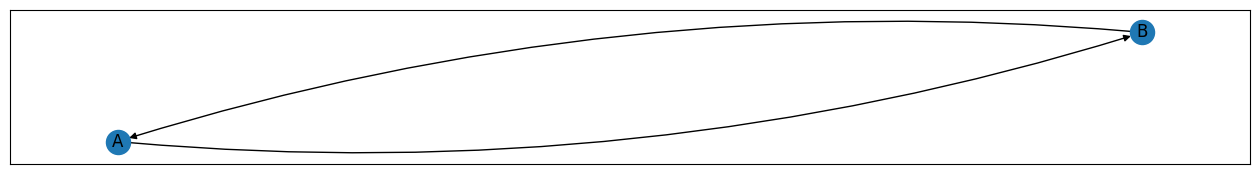

In [51]:
plt.figure(figsize=(16,2)) 
nx.draw_networkx(graph, connectionstyle="arc3,rad=0.1")